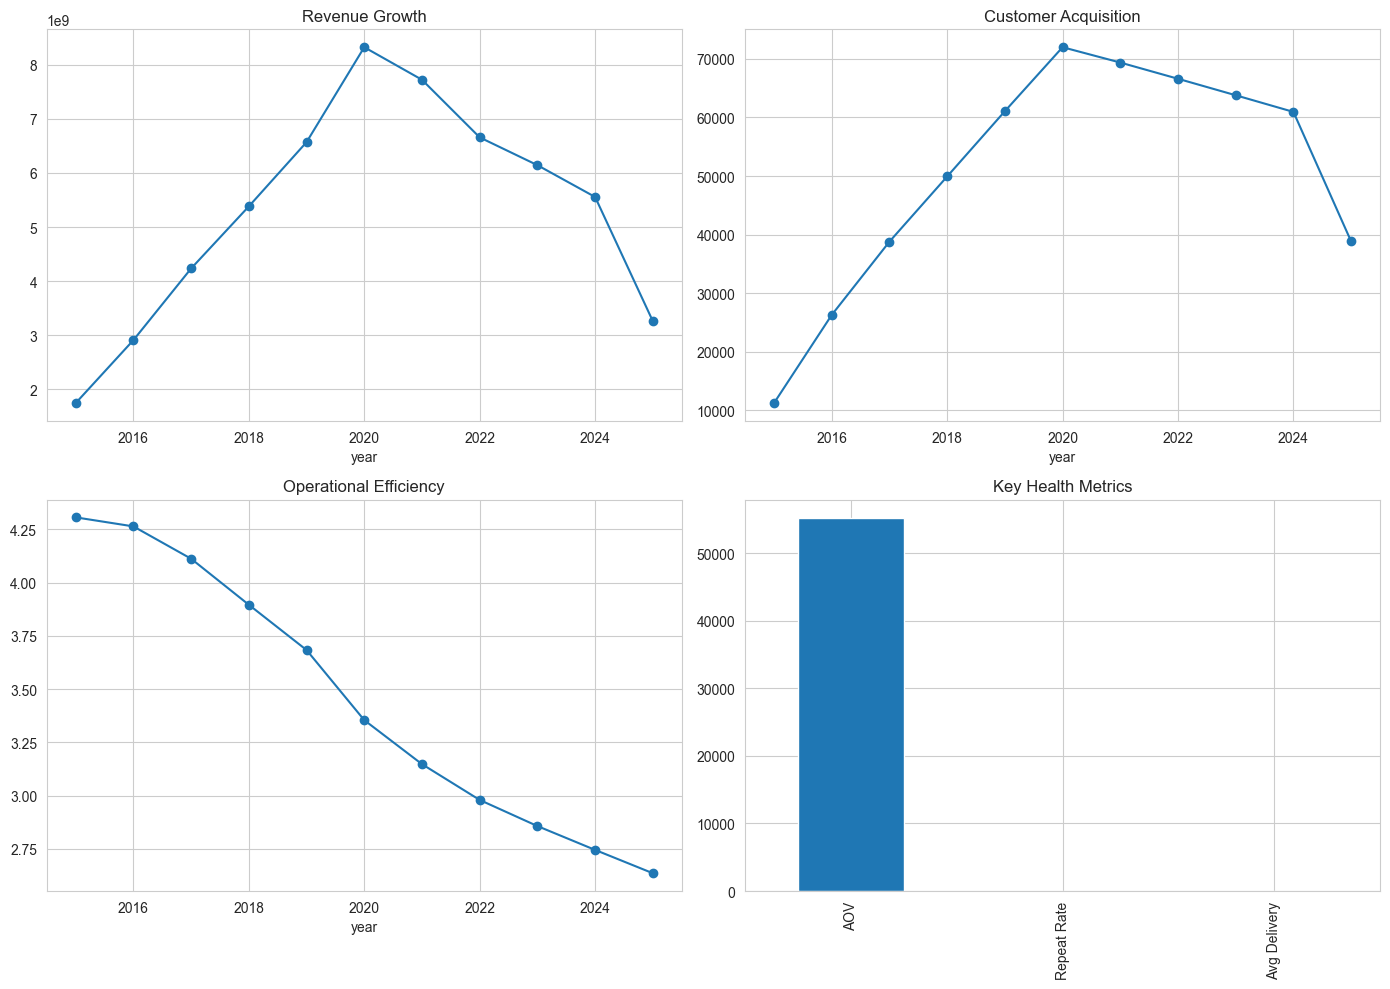

Executive Summary
Total Revenue: 58513485096.46001
Active Customers: 354969
Average Order Value: 55199.682553712955
Repeat Customer Rate: 74.26113266228882
Avg Delivery Days: 3.3221243908247815


In [26]:
#20 Business health dashboard in notebook form
total_revenue = df["final_amount_inr"].sum()
active_customers = df["customer_id"].nunique()
avg_order_value = df["final_amount_inr"].mean()

repeat_customers = df.groupby("customer_id")["transaction_id"].count()
repeat_rate = (repeat_customers.gt(1).sum() / repeat_customers.count()) * 100 if repeat_customers.count() > 0 else np.nan

avg_delivery = df["delivery_days"].mean() if "delivery_days" in df.columns else np.nan

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

yearly_revenue = df.groupby("year")["final_amount_inr"].sum()
yearly_revenue.plot(ax=axes[0, 0], marker="o", title="Revenue Growth")

customer_growth = df.groupby("year")["customer_id"].nunique()
customer_growth.plot(ax=axes[0, 1], marker="o", title="Customer Acquisition")

if "delivery_days" in df.columns:
    df.groupby("year")["delivery_days"].mean().plot(ax=axes[1, 0], marker="o", title="Operational Efficiency")

pd.Series({
    "AOV": avg_order_value,
    "Repeat Rate": repeat_rate,
    "Avg Delivery": avg_delivery
}).plot(kind="bar", ax=axes[1, 1], title="Key Health Metrics")

plt.tight_layout()
plt.show()

print("Executive Summary")
print("Total Revenue:", total_revenue)
print("Active Customers:", active_customers)
print("Average Order Value:", avg_order_value)
print("Repeat Customer Rate:", repeat_rate)
print("Avg Delivery Days:", avg_delivery)

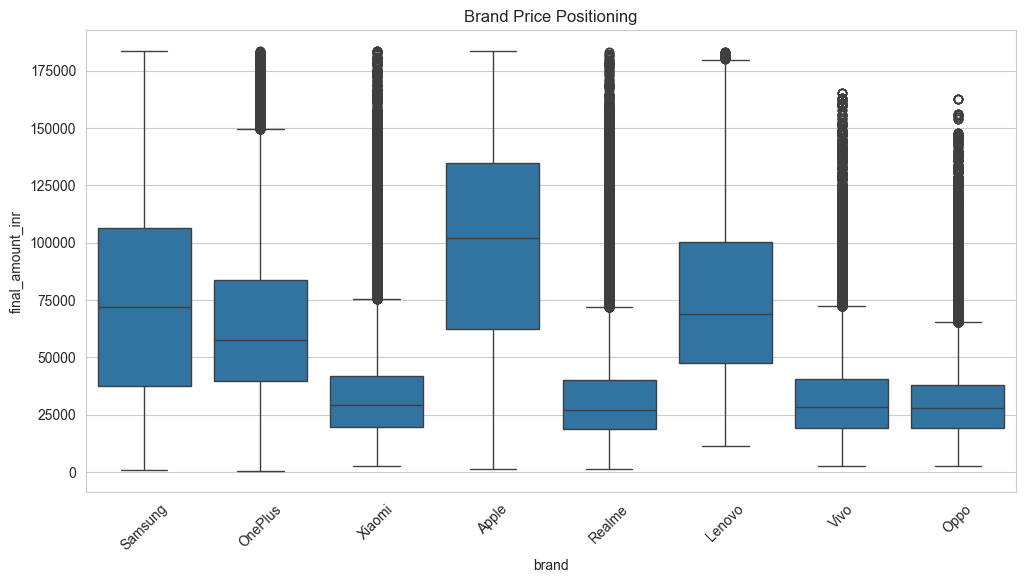

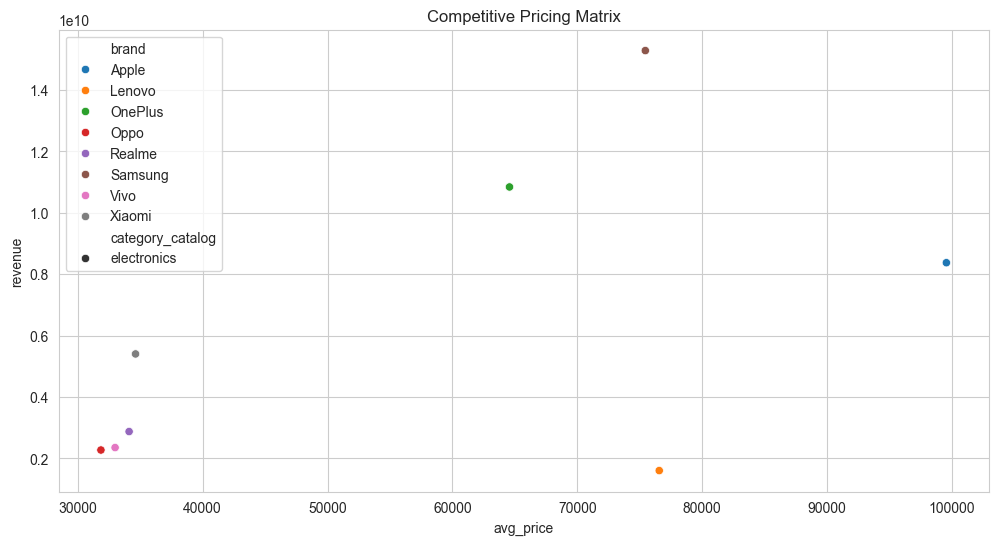

Insight: This compares brand positioning by price and market penetration.


In [25]:
#19 Competitive pricing analysis
if "brand" in df.columns and category_col:
    pricing = df.groupby([category_col, "brand"]).agg(
        avg_price=("final_amount_inr", "mean"),
        revenue=("final_amount_inr", "sum")
    ).reset_index()

    top_brands = pricing.groupby("brand")["revenue"].sum().nlargest(8).index
    pricing = pricing[pricing["brand"].isin(top_brands)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[df["brand"].isin(top_brands)], x="brand", y="final_amount_inr")
    plt.xticks(rotation=45)
    plt.title("Brand Price Positioning")
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.scatterplot(data=pricing, x="avg_price", y="revenue", hue="brand", style=category_col)
    plt.title("Competitive Pricing Matrix")
    plt.show()

print("Insight: This compares brand positioning by price and market penetration.")

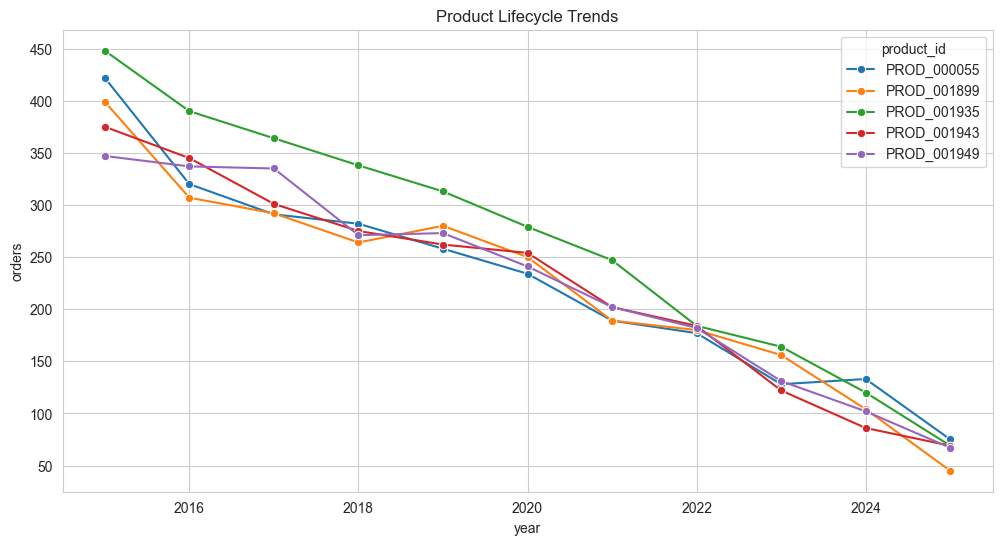

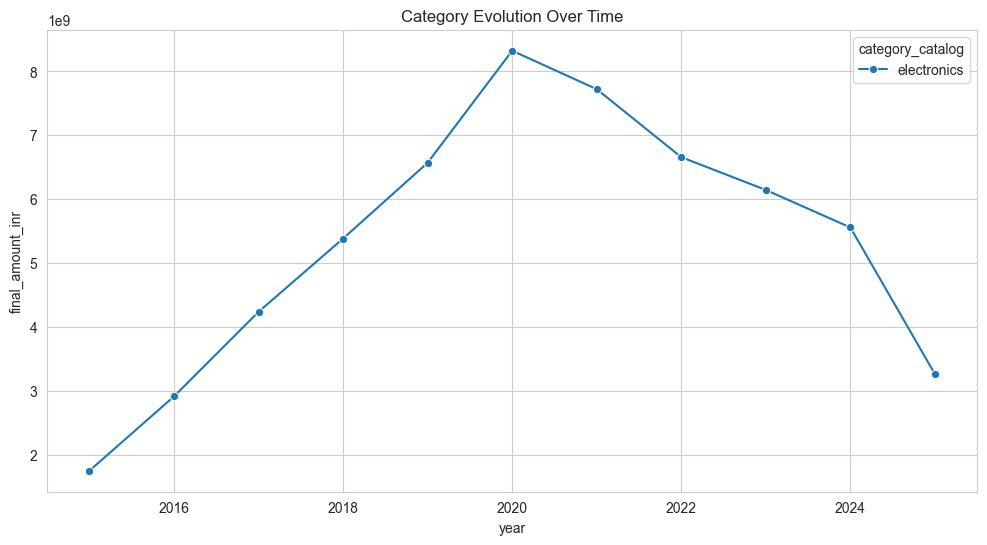

Insight: Lifecycle charts reveal launch strength, decline phases, and category evolution.


In [24]:
#18 Inventory and product lifecycle patterns
if "product_id" in df.columns:
    product_lifecycle = df.groupby(["year", "product_id"])["transaction_id"].count().reset_index(name="orders")
    top_products = product_lifecycle.groupby("product_id")["orders"].sum().nlargest(5).index
    product_lifecycle = product_lifecycle[product_lifecycle["product_id"].isin(top_products)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=product_lifecycle, x="year", y="orders", hue="product_id", marker="o")
    plt.title("Product Lifecycle Trends")
    plt.show()

if category_col:
    category_evolution = df.groupby(["year", category_col])["final_amount_inr"].sum().reset_index()
    top_categories = category_evolution.groupby(category_col)["final_amount_inr"].sum().nlargest(5).index
    category_evolution = category_evolution[category_evolution[category_col].isin(top_categories)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=category_evolution, x="year", y="final_amount_inr", hue=category_col, marker="o")
    plt.title("Category Evolution Over Time")
    plt.show()

print("Insight: Lifecycle charts reveal launch strength, decline phases, and category evolution.")

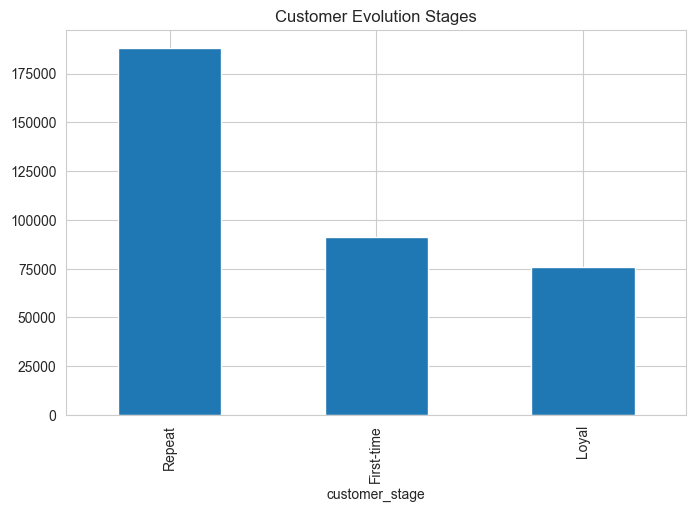

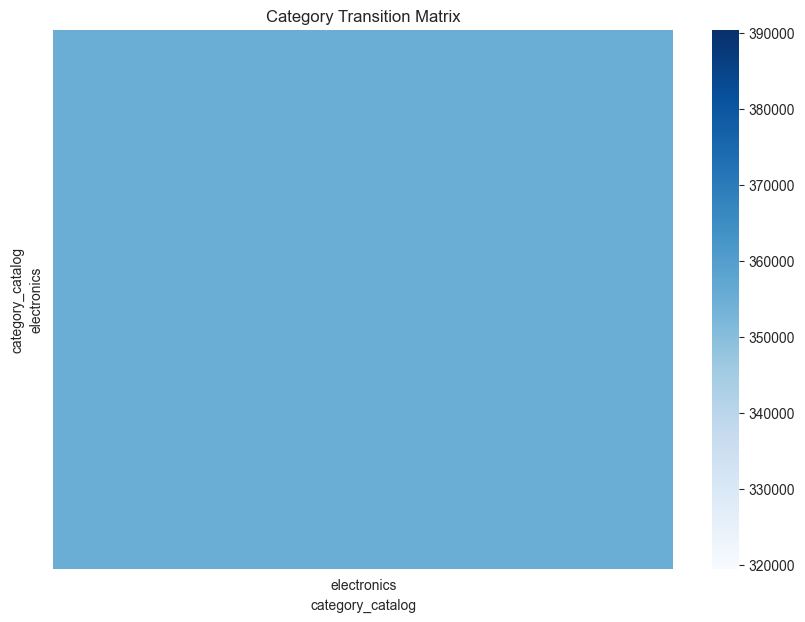

Insight: This approximates customer journey and category transitions over time.


In [23]:
#17 Customer journey analysis
customer_orders = df.groupby("customer_id").agg(
    total_orders=("transaction_id", "count"),
    first_purchase=("order_date", "min"),
    last_purchase=("order_date", "max")
).reset_index()

customer_orders["customer_stage"] = np.where(
    customer_orders["total_orders"] == 1, "First-time",
    np.where(customer_orders["total_orders"] <= 4, "Repeat", "Loyal")
)

stage_counts = customer_orders["customer_stage"].value_counts()

plt.figure(figsize=(8, 5))
stage_counts.plot(kind="bar")
plt.title("Customer Evolution Stages")
plt.show()

if category_col:
    first_category = df.sort_values("order_date").groupby("customer_id")[category_col].first()
    last_category = df.sort_values("order_date").groupby("customer_id")[category_col].last()
    transition = pd.crosstab(first_category, last_category)

    plt.figure(figsize=(10, 7))
    sns.heatmap(transition, cmap="Blues")
    plt.title("Category Transition Matrix")
    plt.show()

print("Insight: This approximates customer journey and category transitions over time.")

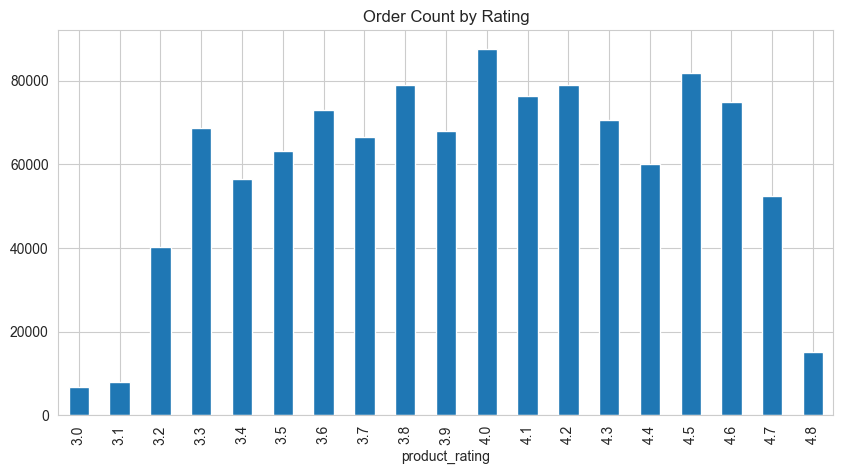

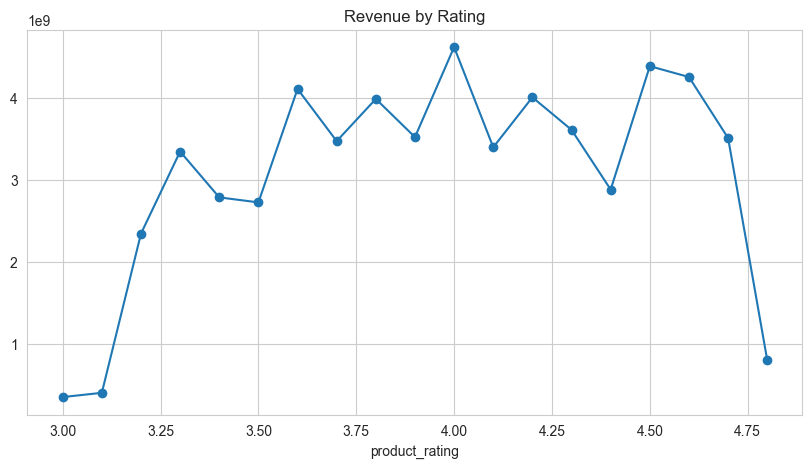

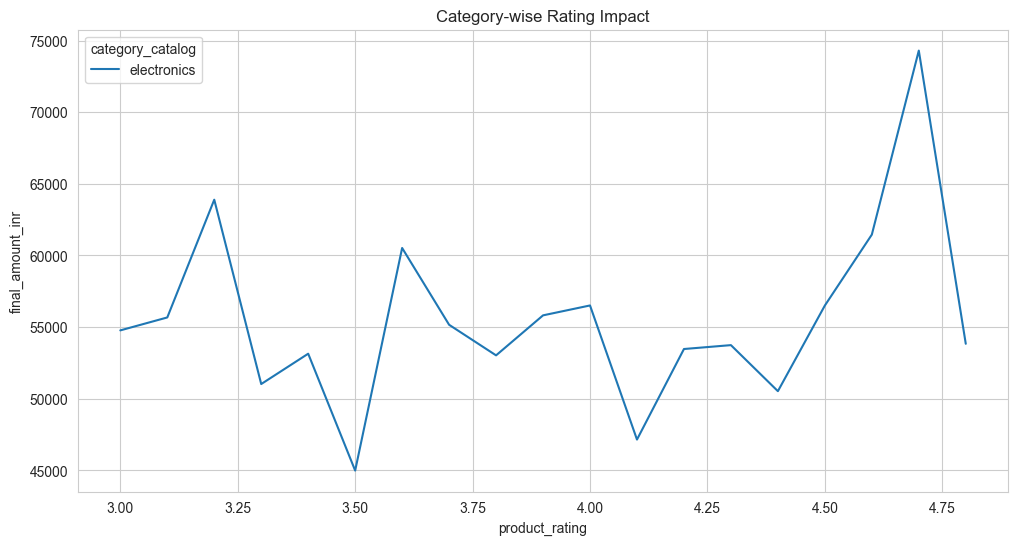

Insight: Product rating patterns show how quality perception relates to sales.


In [22]:
#16 Product rating patterns and impact on sales
rating_col = "product_rating" if "product_rating" in df.columns else ("customer_rating" if "customer_rating" in df.columns else None)

if rating_col:
    rating_sales = df.groupby(rating_col).agg(
        revenue=("final_amount_inr", "sum"),
        orders=("transaction_id", "count")
    )

    plt.figure(figsize=(10, 5))
    rating_sales["orders"].plot(kind="bar")
    plt.title("Order Count by Rating")
    plt.show()

    plt.figure(figsize=(10, 5))
    rating_sales["revenue"].plot(kind="line", marker="o")
    plt.title("Revenue by Rating")
    plt.show()

    if category_col:
        category_rating = df.groupby([category_col, rating_col])["final_amount_inr"].mean().reset_index()
        plt.figure(figsize=(12, 6))
        sns.lineplot(data=category_rating, x=rating_col, y="final_amount_inr", hue=category_col)
        plt.title("Category-wise Rating Impact")
        plt.show()

print("Insight: Product rating patterns show how quality perception relates to sales.")

                  sales_volume       revenue  avg_order_value
discount_percent                                             
0                       505903  2.951431e+10     63940.121258
1-10                     53985  3.042367e+09     60835.174689
11-20                   140455  7.579012e+09     57320.788751
21-30                   172913  8.787440e+09     53098.238241
31-50                   126938  5.557646e+09     44795.520860
50+                     127415  4.032708e+09     31841.859980


C:\Users\Deepesh\AppData\Local\Temp\ipykernel_14416\749704147.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  promo_analysis = df.groupby(discount_bins).agg(


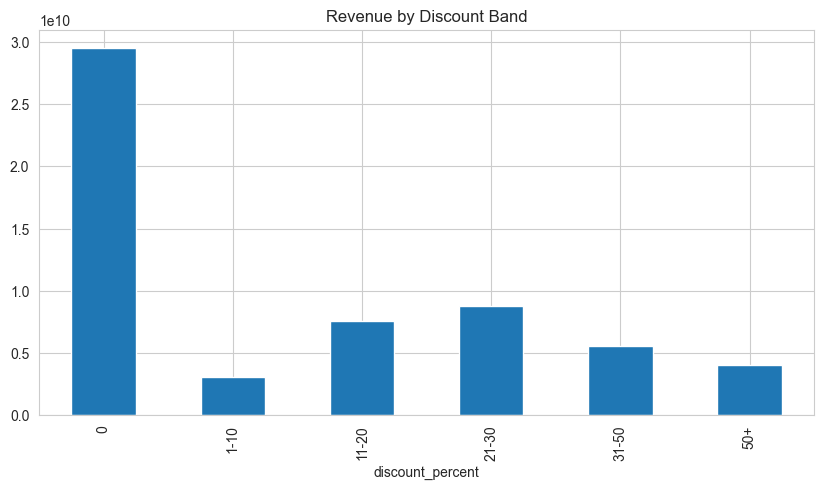

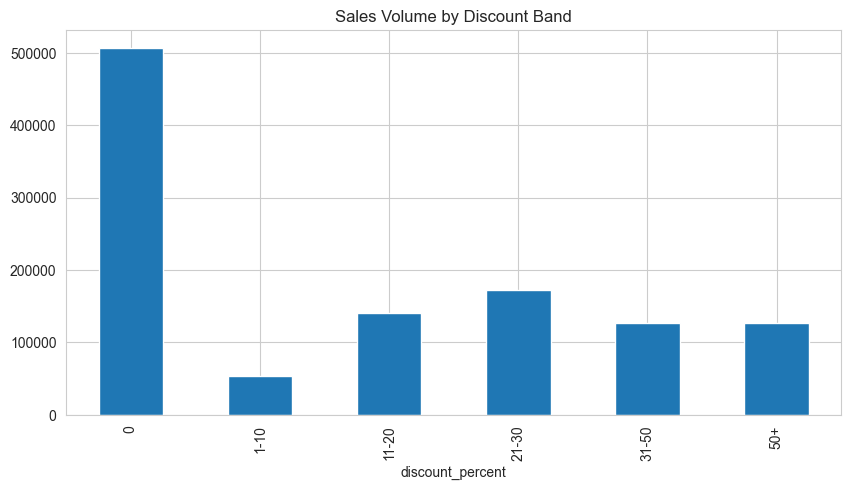

Insight: Discounts can be compared by revenue, volume, and average order value.


In [21]:
#15 Discount and promotional effectiveness
if "discount_percent" in df.columns:
    discount_bins = pd.cut(df["discount_percent"], bins=[-1, 0, 10, 20, 30, 50, 100], labels=["0", "1-10", "11-20", "21-30", "31-50", "50+"])
    promo_analysis = df.groupby(discount_bins).agg(
        sales_volume=("transaction_id", "count"),
        revenue=("final_amount_inr", "sum"),
        avg_order_value=("final_amount_inr", "mean")
    )

    print(promo_analysis)

    plt.figure(figsize=(10, 5))
    promo_analysis["revenue"].plot(kind="bar")
    plt.title("Revenue by Discount Band")
    plt.show()

    plt.figure(figsize=(10, 5))
    promo_analysis["sales_volume"].plot(kind="bar")
    plt.title("Sales Volume by Discount Band")
    plt.show()

print("Insight: Discounts can be compared by revenue, volume, and average order value.")

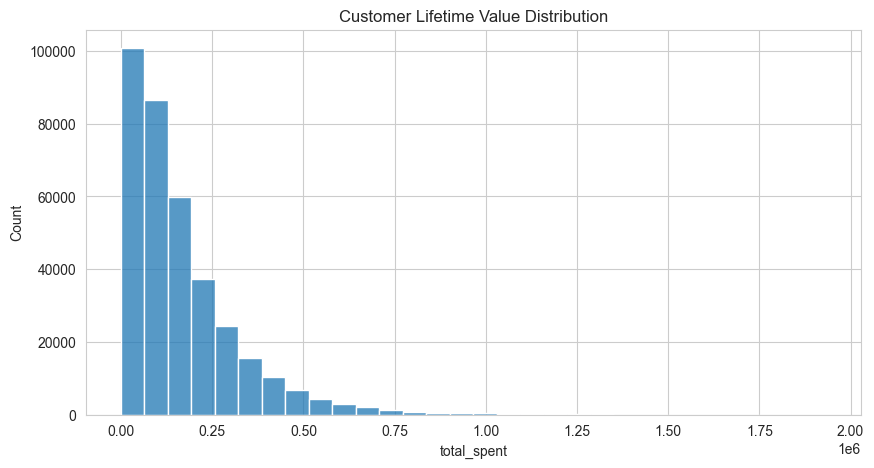

                        avg_clv  customers
acquisition_year                          
2015              425498.189409      11222
2016              289547.177790      17022
2017              234930.825670      24063
2018              202337.697954      31249
2019              179520.367162      38278
2020              167438.989128      45193
2021              151901.786316      43559
2022              130091.153942      41837
2023              113970.413036      40085
2024               98099.231074      38234
2025               83237.165072      24227


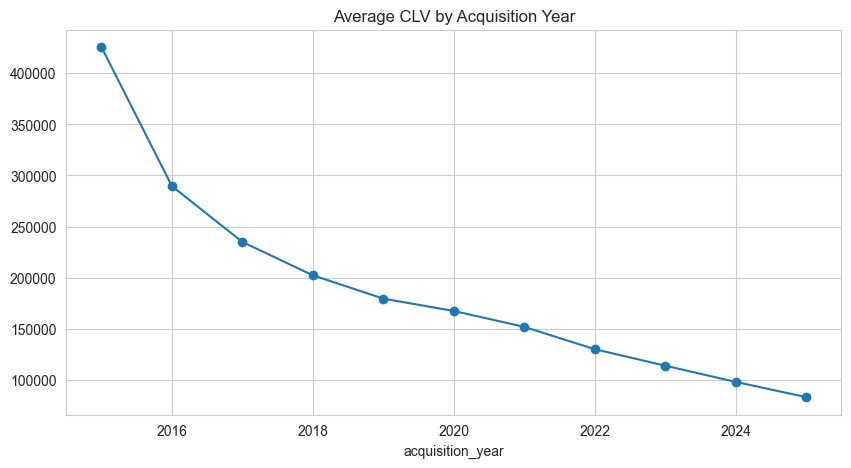

Insight: CLV helps identify valuable acquisition cohorts and long-term customer value.


In [20]:
#14 CLV and cohort analysis
clv = df.groupby("customer_id").agg(
    total_spent=("final_amount_inr", "sum"),
    orders=("transaction_id", "count"),
    first_purchase=("order_date", "min")
).reset_index()

clv["acquisition_year"] = clv["first_purchase"].dt.year

plt.figure(figsize=(10, 5))
sns.histplot(clv["total_spent"], bins=30)
plt.title("Customer Lifetime Value Distribution")
plt.show()

cohort = clv.groupby("acquisition_year").agg(
    avg_clv=("total_spent", "mean"),
    customers=("customer_id", "count")
)

print(cohort)

plt.figure(figsize=(10, 5))
cohort["avg_clv"].plot(marker="o")
plt.title("Average CLV by Acquisition Year")
plt.show()

print("Insight: CLV helps identify valuable acquisition cohorts and long-term customer value.")

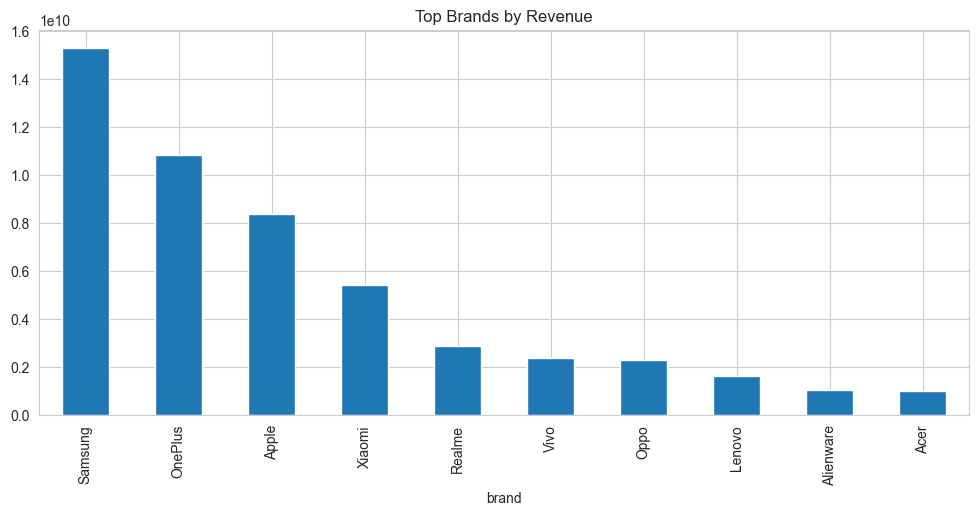

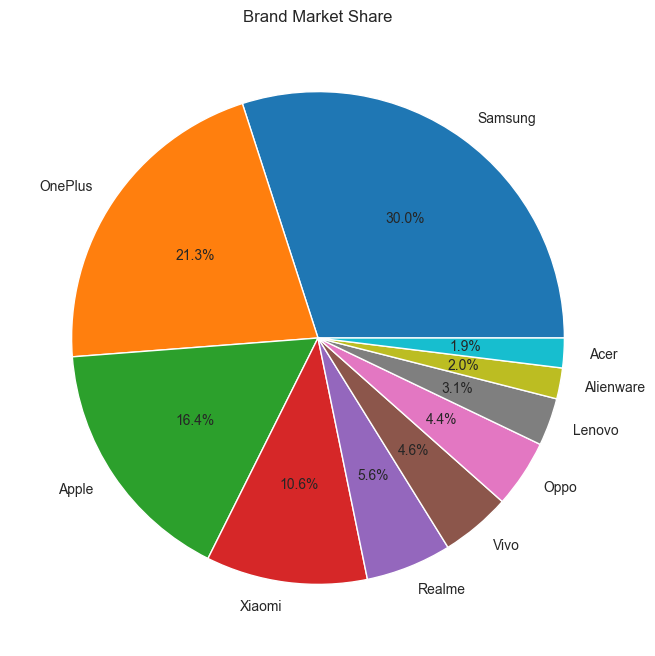

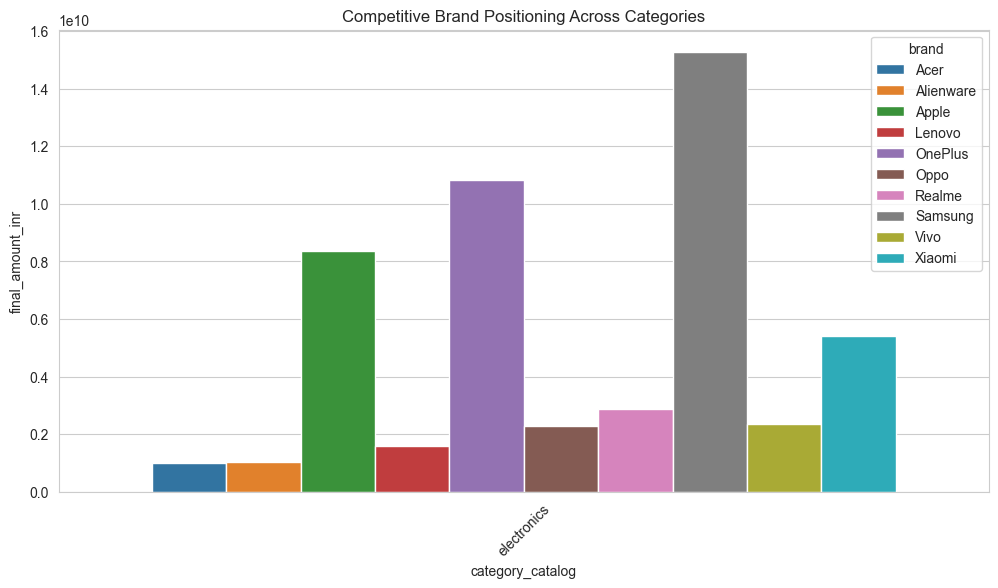

Insight: Brand revenue and market share show category leaders and competitive position.


In [19]:
#13 Brand performance and market share
if "brand" in df.columns:
    brand_perf = df.groupby("brand")["final_amount_inr"].sum().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 5))
    brand_perf.plot(kind="bar")
    plt.title("Top Brands by Revenue")
    plt.show()

    brand_share = df.groupby("brand")["final_amount_inr"].sum()
    brand_share = (brand_share / brand_share.sum() * 100).sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 8))
    brand_share.plot(kind="pie", autopct="%1.1f%%")
    plt.title("Brand Market Share")
    plt.ylabel("")
    plt.show()

    if category_col:
        brand_category = df.groupby([category_col, "brand"])["final_amount_inr"].sum().reset_index()
        top_brands = brand_perf.index
        brand_category = brand_category[brand_category["brand"].isin(top_brands)]

        plt.figure(figsize=(12, 6))
        sns.barplot(data=brand_category, x=category_col, y="final_amount_inr", hue="brand")
        plt.xticks(rotation=45)
        plt.title("Competitive Brand Positioning Across Categories")
        plt.show()

print("Insight: Brand revenue and market share show category leaders and competitive position.")

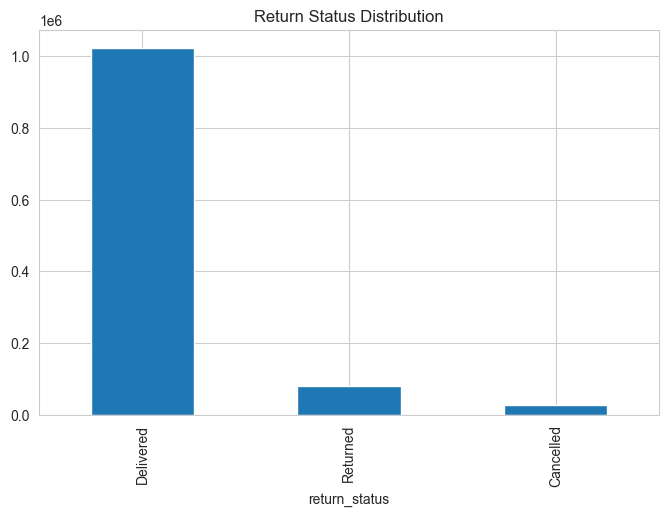

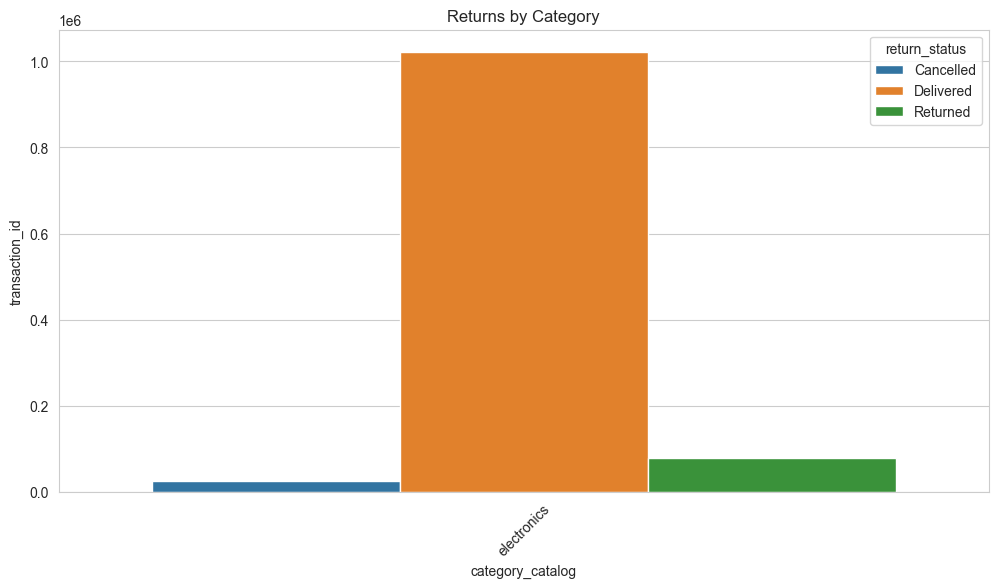

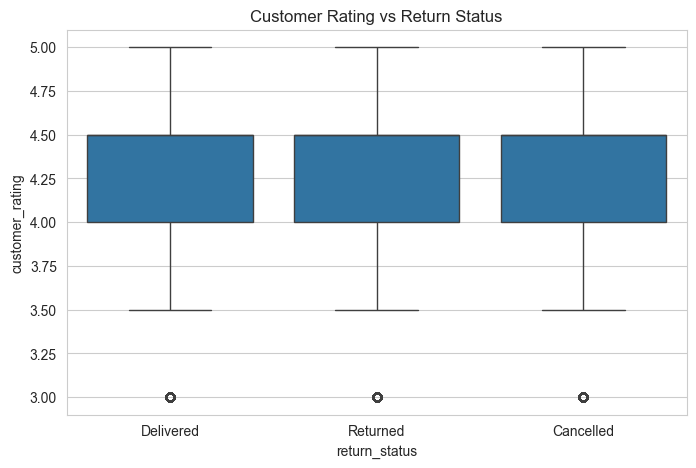

Insight: Returns can be analyzed against category, price, and ratings to locate quality issues.


In [18]:
#12 Return patterns and customer satisfaction
if "return_status" in df.columns:
    return_counts = df["return_status"].value_counts()

    plt.figure(figsize=(8, 5))
    return_counts.plot(kind="bar")
    plt.title("Return Status Distribution")
    plt.show()

    if category_col:
        return_category = df.groupby([category_col, "return_status"])["transaction_id"].count().reset_index()
        plt.figure(figsize=(12, 6))
        sns.barplot(data=return_category, x=category_col, y="transaction_id", hue="return_status")
        plt.xticks(rotation=45)
        plt.title("Returns by Category")
        plt.show()

    if "customer_rating" in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x="return_status", y="customer_rating")
        plt.title("Customer Rating vs Return Status")
        plt.show()

print("Insight: Returns can be analyzed against category, price, and ratings to locate quality issues.")

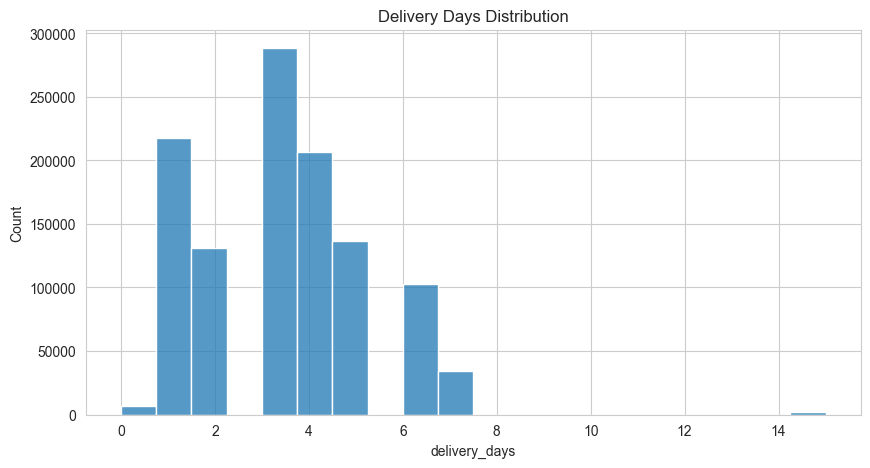

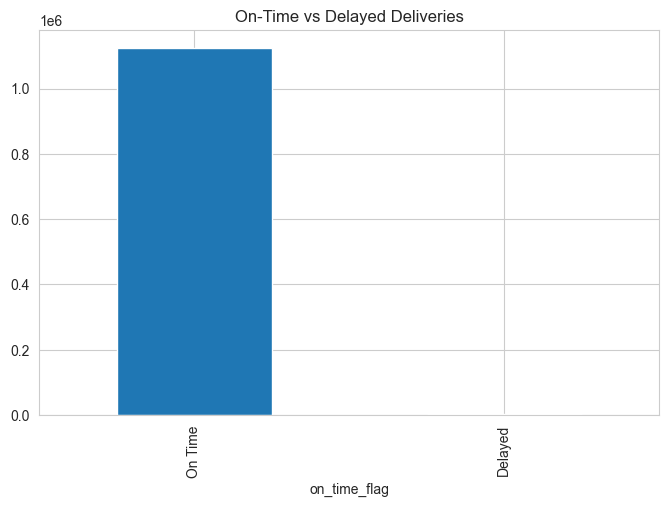

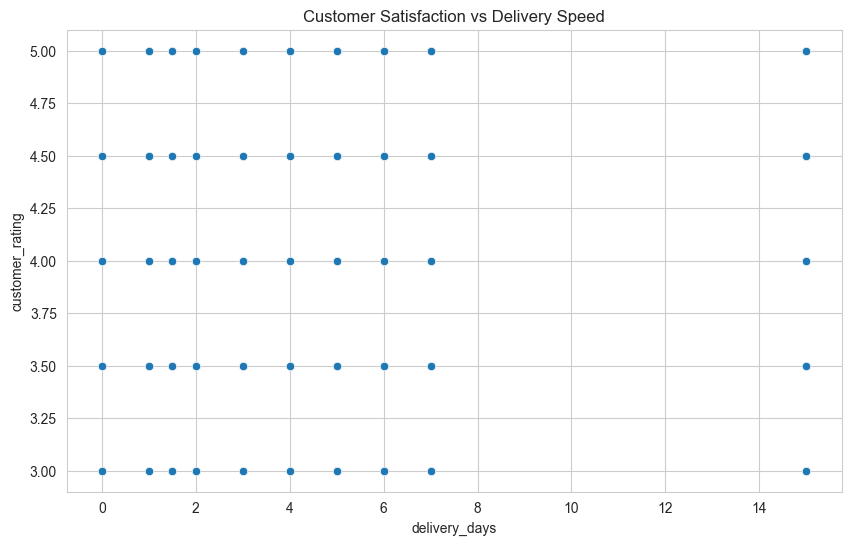

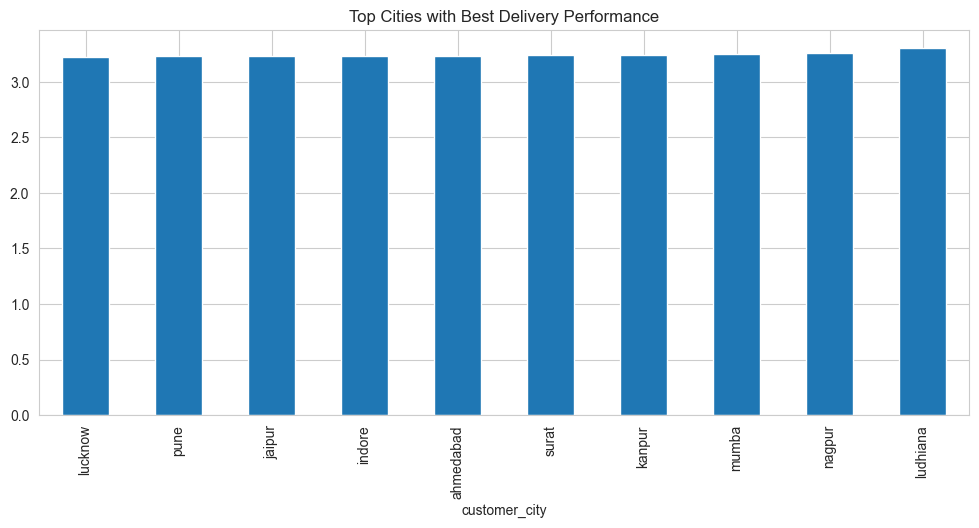

Insight: Delivery performance is tied to customer experience and regional efficiency.


In [15]:
#11 Delivery performance analysis
if "delivery_days" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df["delivery_days"].dropna(), bins=20)
    plt.title("Delivery Days Distribution")
    plt.show()

    df["on_time_flag"] = np.where(df["delivery_days"] <= 7, "On Time", "Delayed")
    on_time_counts = df["on_time_flag"].value_counts()

    plt.figure(figsize=(8, 5))
    on_time_counts.plot(kind="bar")
    plt.title("On-Time vs Delayed Deliveries")
    plt.show()

    if "customer_rating" in df.columns:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x="delivery_days", y="customer_rating")
        plt.title("Customer Satisfaction vs Delivery Speed")
        plt.show()

    if "customer_city" in df.columns:
        city_delivery = df.groupby("customer_city")["delivery_days"].mean().sort_values().head(10)
        plt.figure(figsize=(12, 5))
        city_delivery.plot(kind="bar")
        plt.title("Top Cities with Best Delivery Performance")
        plt.show()

print("Insight: Delivery performance is tied to customer experience and regional efficiency.")

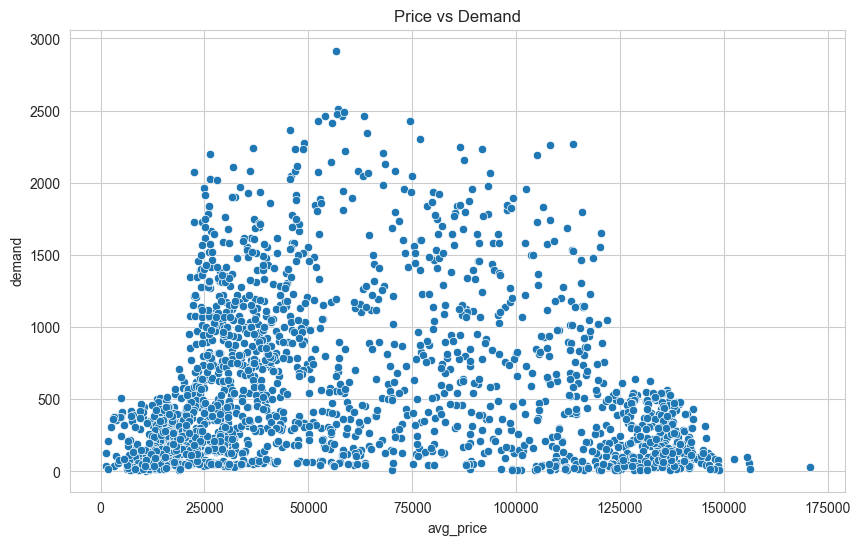

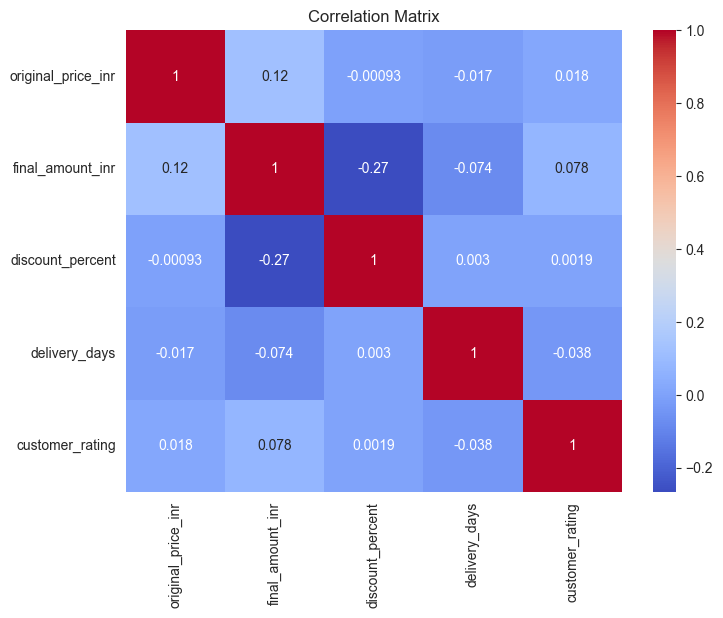

Insight: This helps assess pricing strategy, demand sensitivity, and variable relationships.


In [14]:
#10 Price vs demand analysis
price_demand = df.groupby("product_id").agg(
    avg_price=("final_amount_inr", "mean"),
    demand=("transaction_id", "count")
).reset_index()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=price_demand, x="avg_price", y="demand")
plt.title("Price vs Demand")
plt.show()

corr_cols = ["original_price_inr", "final_amount_inr", "discount_percent", "delivery_days", "customer_rating"]
corr_cols = [c for c in corr_cols if c in df.columns]

if corr_cols:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Matrix")
    plt.show()

print("Insight: This helps assess pricing strategy, demand sensitivity, and variable relationships.")

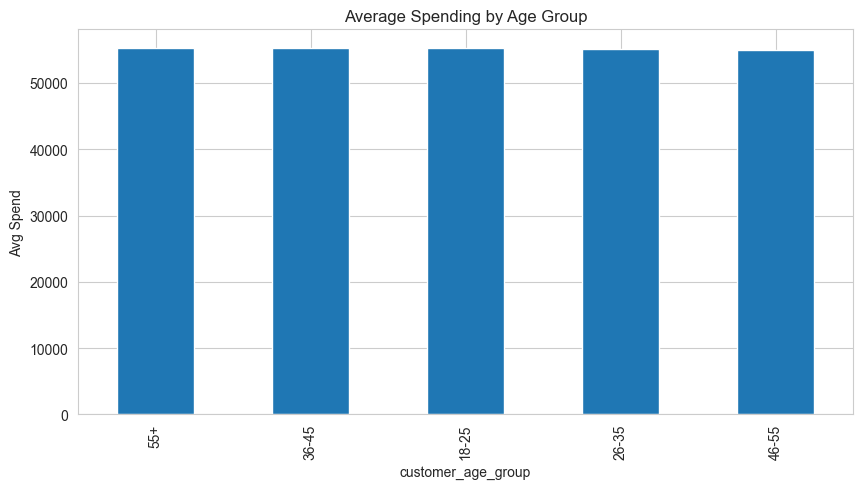

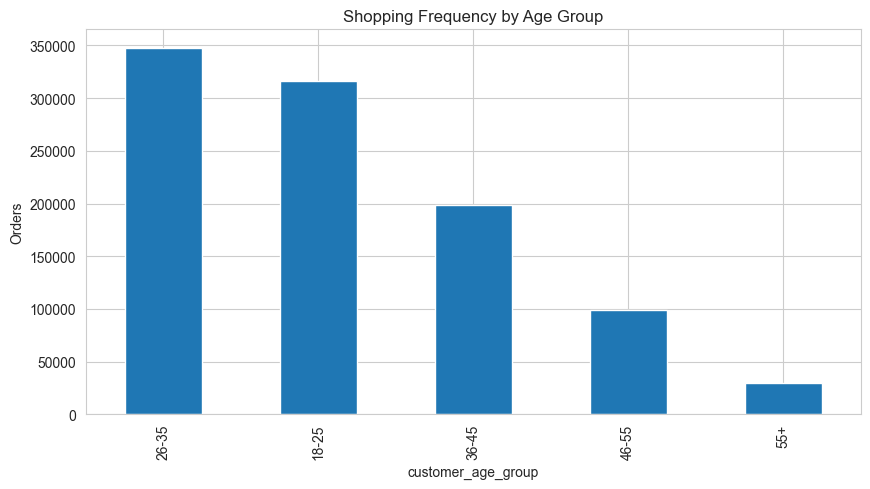

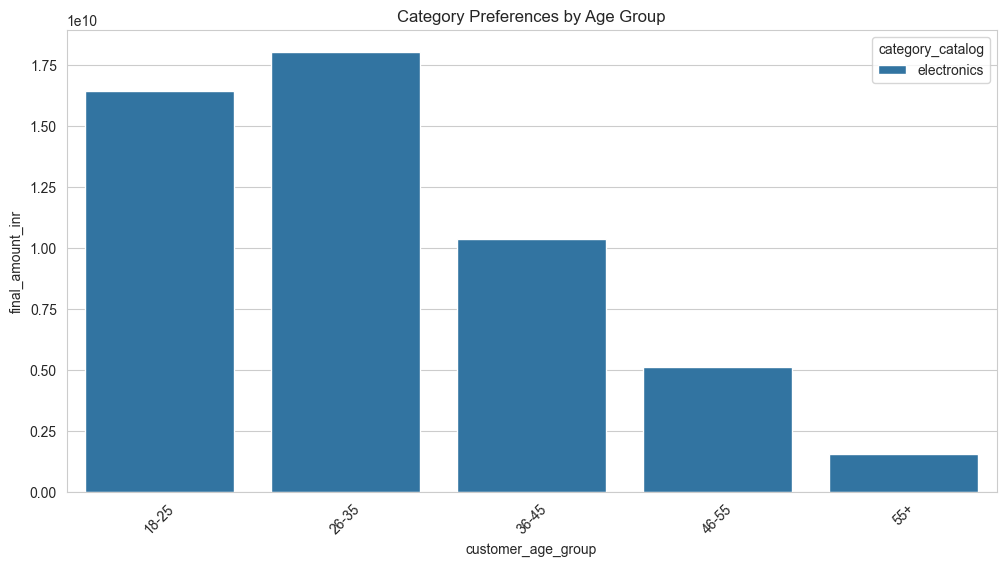

Insight:
- Different age groups show different spending behaviors.
- Younger users may prefer electronics/fashion.
- Older users may prefer home/kitchen or essentials.


In [17]:
#9 Age-group behavior
age_col = "customer_age_group"

if age_col in df.columns and df[age_col].notna().sum() > 0:

    age_spend = df.groupby(age_col)["final_amount_inr"].mean().sort_values(ascending=False)
    age_orders = df.groupby(age_col)["transaction_id"].count().sort_values(ascending=False)

    plt.figure(figsize=(10, 5))
    age_spend.plot(kind="bar")
    plt.title("Average Spending by Age Group")
    plt.ylabel("Avg Spend")
    plt.show()

    plt.figure(figsize=(10, 5))
    age_orders.plot(kind="bar")
    plt.title("Shopping Frequency by Age Group")
    plt.ylabel("Orders")
    plt.show()

    if category_col:
        age_category = df.groupby([age_col, category_col])["final_amount_inr"].sum().reset_index()

        plt.figure(figsize=(12, 6))
        sns.barplot(
            data=age_category,
            x=age_col,
            y="final_amount_inr",
            hue=category_col
        )
        plt.xticks(rotation=45)
        plt.title("Category Preferences by Age Group")
        plt.show()

    print("Insight:")
    print("- Different age groups show different spending behaviors.")
    print("- Younger users may prefer electronics/fashion.")
    print("- Older users may prefer home/kitchen or essentials.")

else:
    print("customer_age_group column exists but has insufficient data.")

                           sum   count          mean
is_festival_sale                                    
False             4.397054e+10  718299  61214.810455
True              1.454295e+10  341734  42556.339029


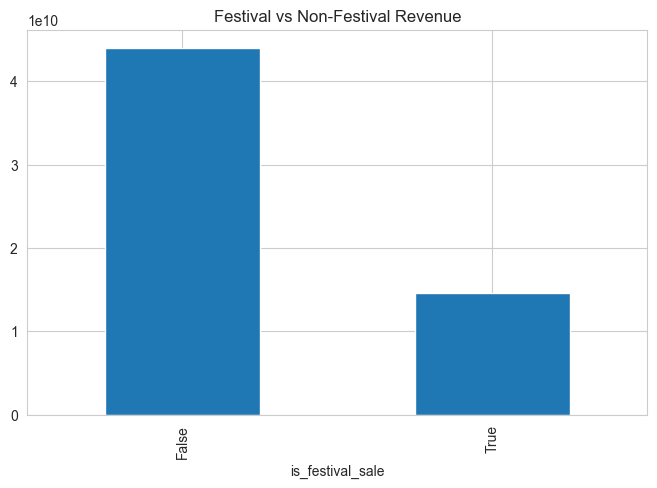

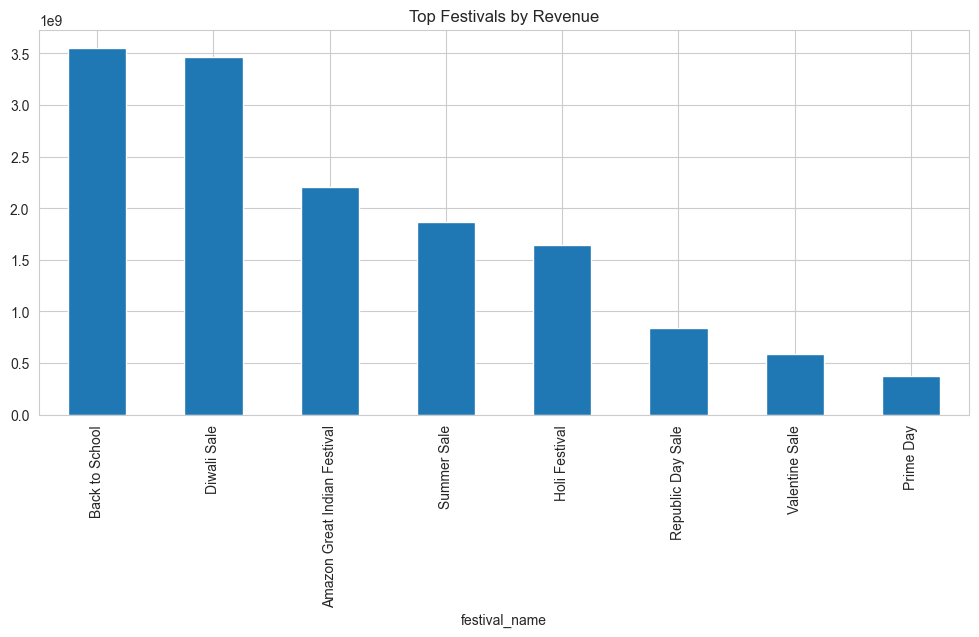

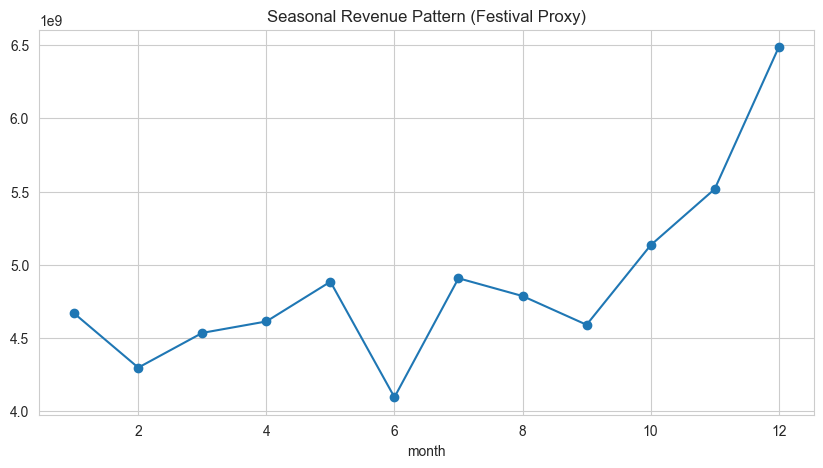

Insight: Festival and seasonal analysis reveals demand spikes during promotional periods.


In [12]:
#8 Festival sales impact
if "is_festival_sale" in df.columns:
    festival_sales = df.groupby("is_festival_sale")["final_amount_inr"].agg(["sum", "count", "mean"])
    print(festival_sales)

    plt.figure(figsize=(8, 5))
    festival_sales["sum"].plot(kind="bar")
    plt.title("Festival vs Non-Festival Revenue")
    plt.show()

if "festival_name" in df.columns:
    fest_name_sales = df.groupby("festival_name")["final_amount_inr"].sum().sort_values(ascending=False).head(10)
    if len(fest_name_sales) > 0:
        plt.figure(figsize=(12, 5))
        fest_name_sales.plot(kind="bar")
        plt.title("Top Festivals by Revenue")
        plt.show()

monthly_festival_proxy = df.groupby("month")["final_amount_inr"].sum()
plt.figure(figsize=(10, 5))
monthly_festival_proxy.plot(marker="o")
plt.title("Seasonal Revenue Pattern (Festival Proxy)")
plt.show()

print("Insight: Festival and seasonal analysis reveals demand spikes during promotional periods.")

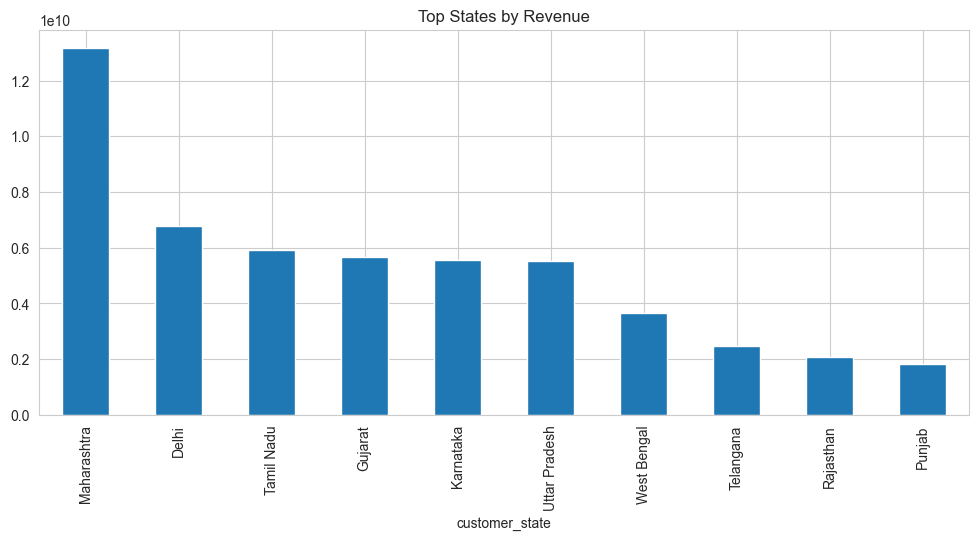

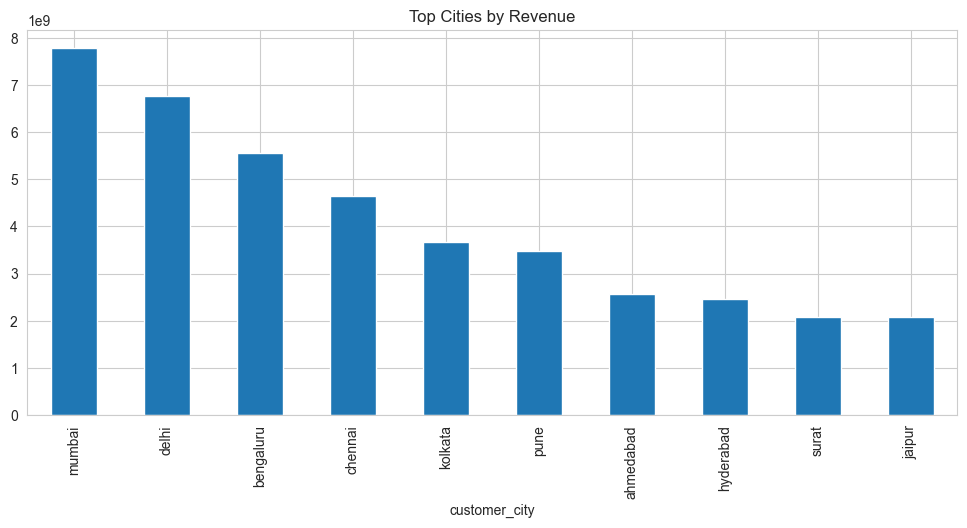

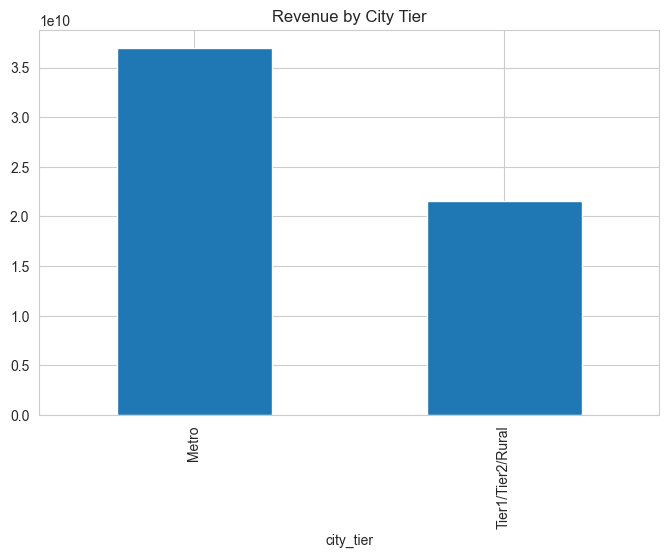

Insight: Geography analysis highlights top revenue regions and broad city-tier patterns.


In [11]:
#7 Geographic analysis
state_revenue = df.groupby("customer_state")["final_amount_inr"].sum().sort_values(ascending=False).head(10)
city_revenue = df.groupby("customer_city")["final_amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
state_revenue.plot(kind="bar")
plt.title("Top States by Revenue")
plt.show()

plt.figure(figsize=(12, 5))
city_revenue.plot(kind="bar")
plt.title("Top Cities by Revenue")
plt.show()

metro = {"mumbai", "delhi", "bengaluru", "chennai", "kolkata", "hyderabad", "pune", "ahmedabad"}
df["city_tier"] = np.where(df["customer_city"].isin(metro), "Metro", "Tier1/Tier2/Rural")

tier_revenue = df.groupby("city_tier")["final_amount_inr"].sum()

plt.figure(figsize=(8, 5))
tier_revenue.plot(kind="bar")
plt.title("Revenue by City Tier")
plt.show()

print("Insight: Geography analysis highlights top revenue regions and broad city-tier patterns.")

                 avg_order_value  order_count
is_prime_member                              
False               52001.888753       698485
True                60603.611642       429124


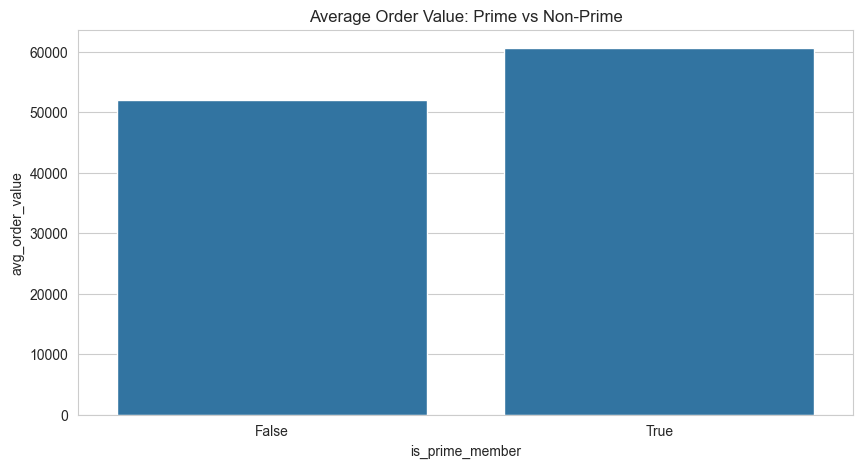

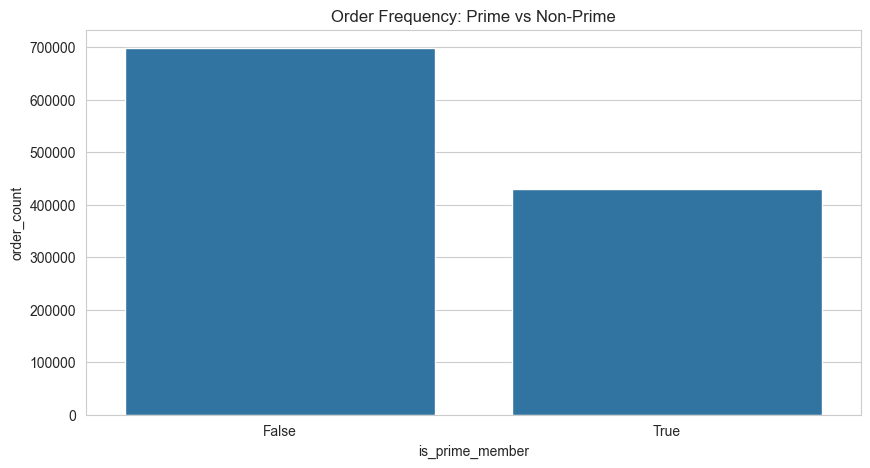

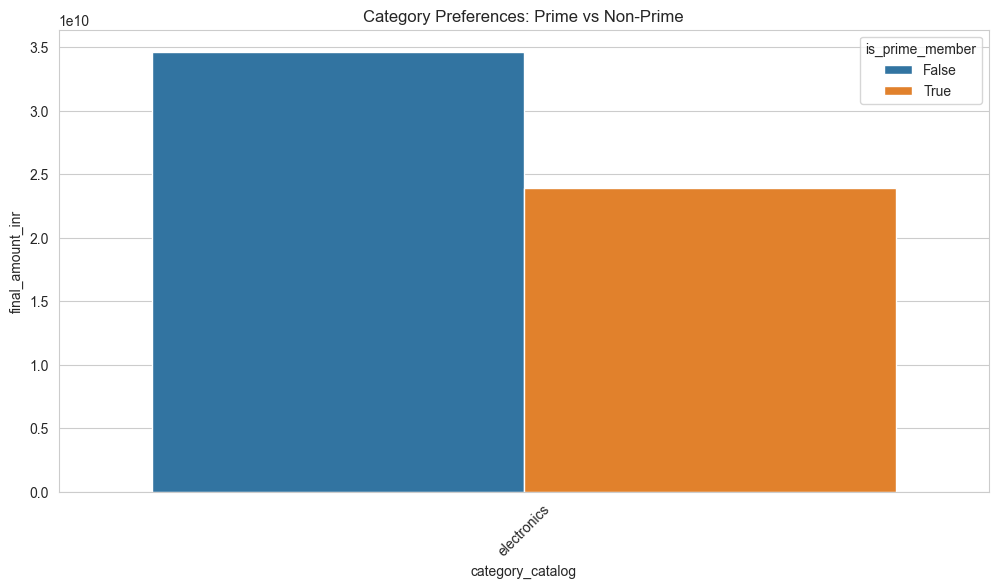

Insight: Prime members can be compared using order value, order volume, and category preference.


In [10]:
#6 Prime membership impact
if "is_prime_member" in df.columns:
    prime_summary = df.groupby("is_prime_member").agg(
        avg_order_value=("final_amount_inr", "mean"),
        order_count=("transaction_id", "count")
    )

    print(prime_summary)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=prime_summary.index.astype(str), y=prime_summary["avg_order_value"])
    plt.title("Average Order Value: Prime vs Non-Prime")
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=prime_summary.index.astype(str), y=prime_summary["order_count"])
    plt.title("Order Frequency: Prime vs Non-Prime")
    plt.show()

    if category_col:
        prime_category = df.groupby(["is_prime_member", category_col])["final_amount_inr"].sum().reset_index()
        plt.figure(figsize=(12, 6))
        sns.barplot(data=prime_category, x=category_col, y="final_amount_inr", hue="is_prime_member")
        plt.xticks(rotation=45)
        plt.title("Category Preferences: Prime vs Non-Prime")
        plt.show()

print("Insight: Prime members can be compared using order value, order volume, and category preference.")

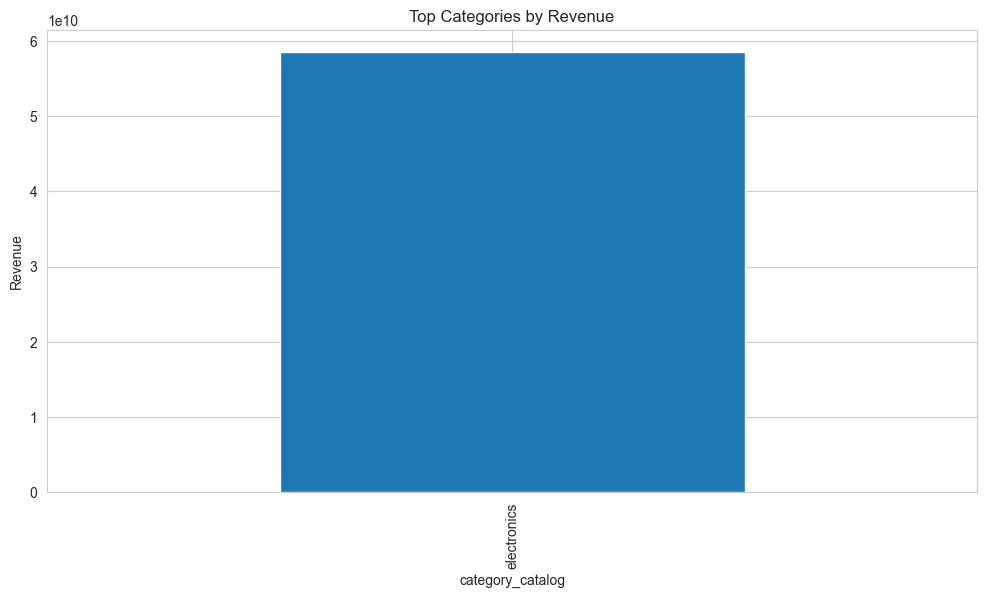

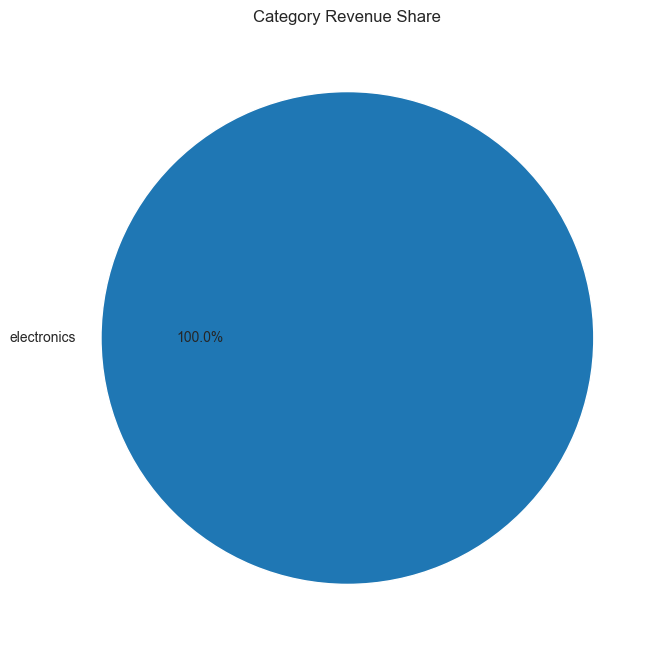

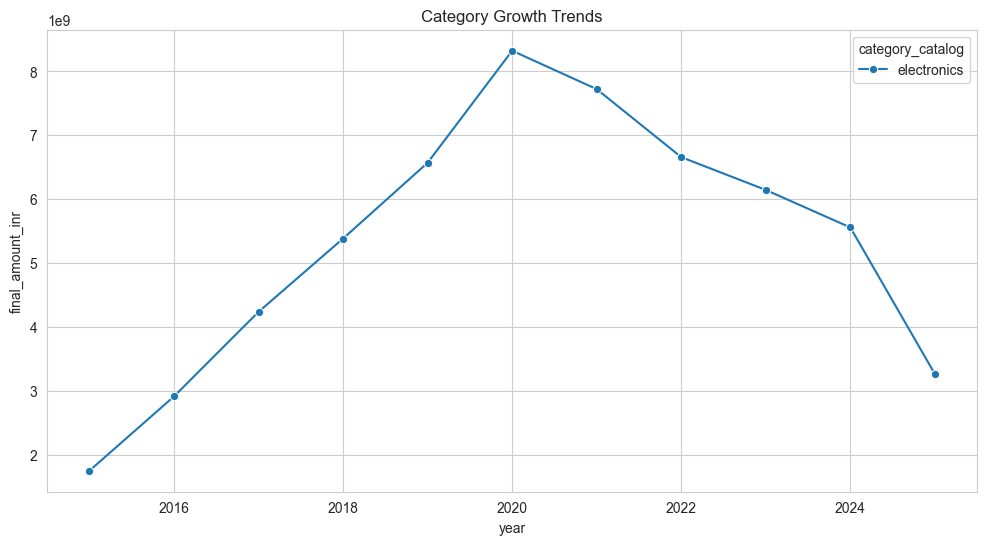

Insight: Category contribution, market share, and growth trends reveal the strongest segments.


In [9]:
#5 Category-wise performance
if category_col:
    category_perf = df.groupby(category_col)["final_amount_inr"].sum().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    category_perf.head(10).plot(kind="bar")
    plt.title("Top Categories by Revenue")
    plt.ylabel("Revenue")
    plt.show()

    plt.figure(figsize=(8, 8))
    category_perf.head(8).plot(kind="pie", autopct="%1.1f%%")
    plt.title("Category Revenue Share")
    plt.ylabel("")
    plt.show()

    category_growth = df.groupby(["year", category_col])["final_amount_inr"].sum().reset_index()
    top_cats = category_perf.head(5).index
    category_growth = category_growth[category_growth[category_col].isin(top_cats)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=category_growth, x="year", y="final_amount_inr", hue=category_col, marker="o")
    plt.title("Category Growth Trends")
    plt.show()

print("Insight: Category contribution, market share, and growth trends reveal the strongest segments.")

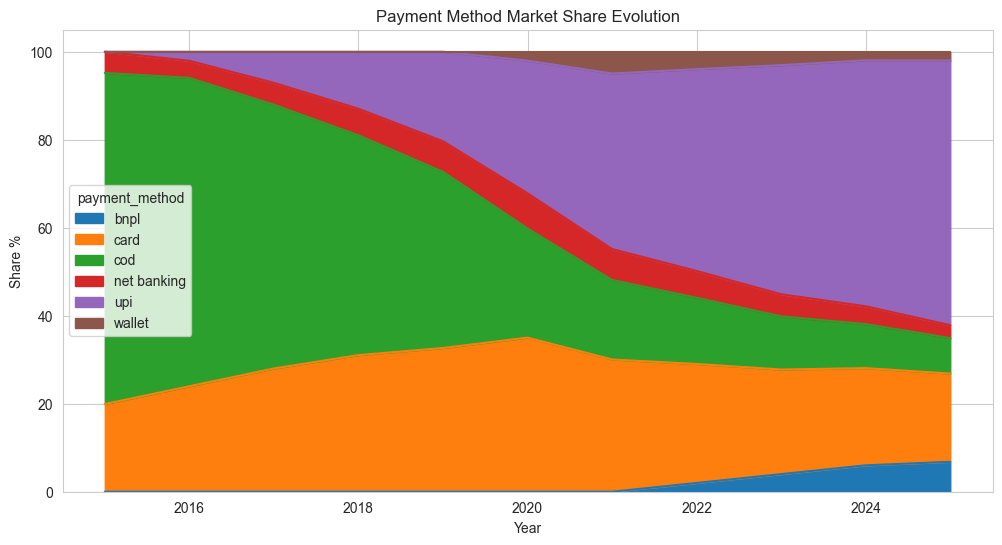

Insight: This shows the rise or decline of payment modes such as UPI and COD over time.


In [8]:
#4 Payment method evolution
payment_trend = df.groupby(["year", "payment_method"]).size().reset_index(name="orders")
payment_pivot = payment_trend.pivot(index="year", columns="payment_method", values="orders").fillna(0)

payment_share = payment_pivot.div(payment_pivot.sum(axis=1), axis=0) * 100

payment_share.plot.area(figsize=(12, 6))
plt.title("Payment Method Market Share Evolution")
plt.xlabel("Year")
plt.ylabel("Share %")
plt.show()

print("Insight: This shows the rise or decline of payment modes such as UPI and COD over time.")

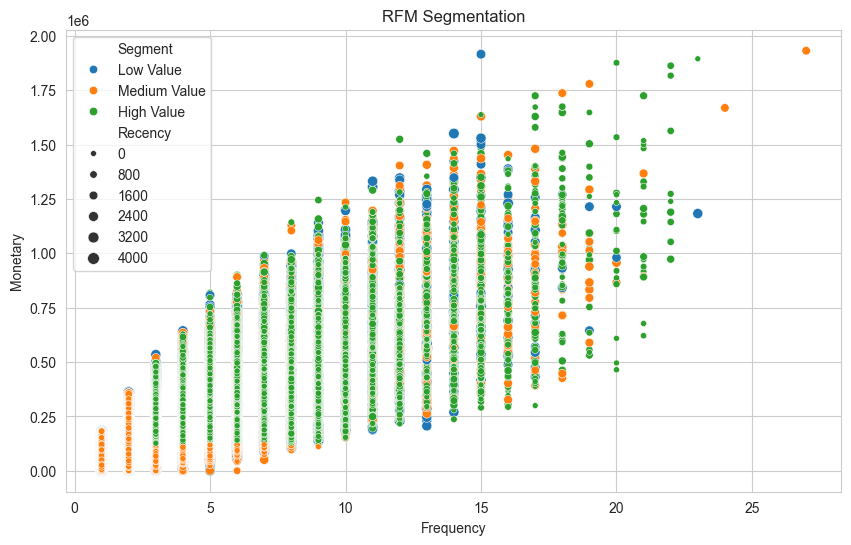

Segment
Low Value       152508
Medium Value    132986
High Value       69475
Name: count, dtype: int64
Insight: RFM helps identify loyal, medium-value, and low-value customers.


In [7]:
#3 RFM customer segmentation
snapshot_date = df["order_date"].max()

rfm = df.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "transaction_id": "count",
    "final_amount_inr": "sum"
}).reset_index()

rfm.columns = ["customer_id", "Recency", "Frequency", "Monetary"]

rfm["R_score"] = pd.qcut(rfm["Recency"].rank(method="first"), 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 4, labels=[1,2,3,4])

rfm["Segment"] = np.where(
    (rfm["R_score"].astype(int) >= 3) & (rfm["F_score"].astype(int) >= 3) & (rfm["M_score"].astype(int) >= 3),
    "High Value",
    np.where(
        (rfm["R_score"].astype(int) >= 2) & (rfm["F_score"].astype(int) >= 2),
        "Medium Value",
        "Low Value"
    )
)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", size="Recency")
plt.title("RFM Segmentation")
plt.show()

print(rfm["Segment"].value_counts())
print("Insight: RFM helps identify loyal, medium-value, and low-value customers.")

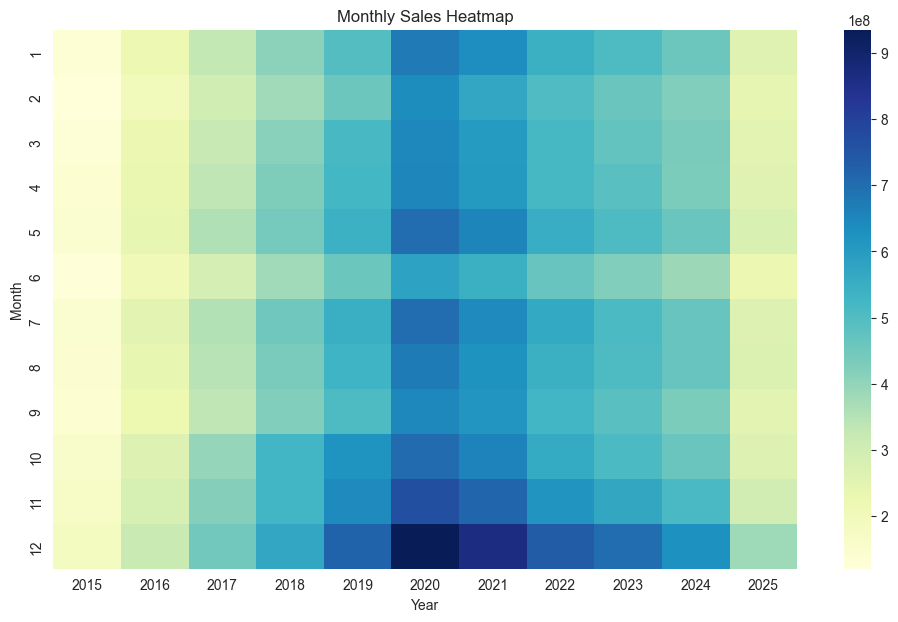

Peak selling months:
month
12    6.484837e+09
11    5.516817e+09
10    5.133371e+09
7     4.907841e+09
5     4.884302e+09
Name: final_amount_inr, dtype: float64


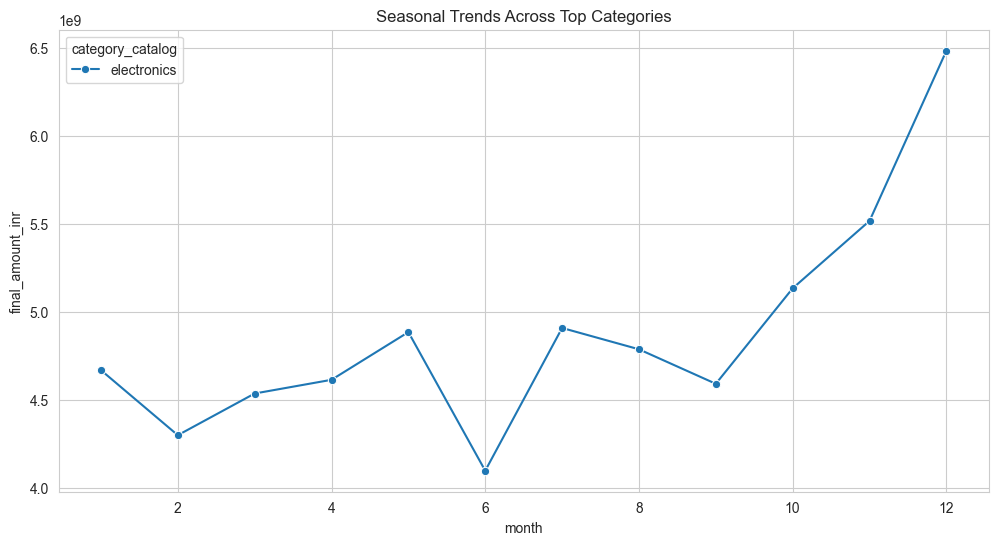

Insight: Heatmap and monthly totals reveal seasonality and peak-demand months.


In [6]:
#2 Seasonal patterns and monthly heatmap
monthly_heatmap = df.pivot_table(
    values="final_amount_inr",
    index="month",
    columns="year",
    aggfunc="sum"
)

plt.figure(figsize=(12, 7))
sns.heatmap(monthly_heatmap, annot=False, cmap="YlGnBu")
plt.title("Monthly Sales Heatmap")
plt.xlabel("Year")
plt.ylabel("Month")
plt.show()

peak_months = df.groupby("month")["final_amount_inr"].sum().sort_values(ascending=False)
print("Peak selling months:")
print(peak_months.head())

if category_col:
    seasonal_category = df.groupby(["month", category_col])["final_amount_inr"].sum().reset_index()
    top_categories = seasonal_category.groupby(category_col)["final_amount_inr"].sum().nlargest(5).index
    seasonal_category = seasonal_category[seasonal_category[category_col].isin(top_categories)]

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=seasonal_category, x="month", y="final_amount_inr", hue=category_col, marker="o")
    plt.title("Seasonal Trends Across Top Categories")
    plt.show()

print("Insight: Heatmap and monthly totals reveal seasonality and peak-demand months.")

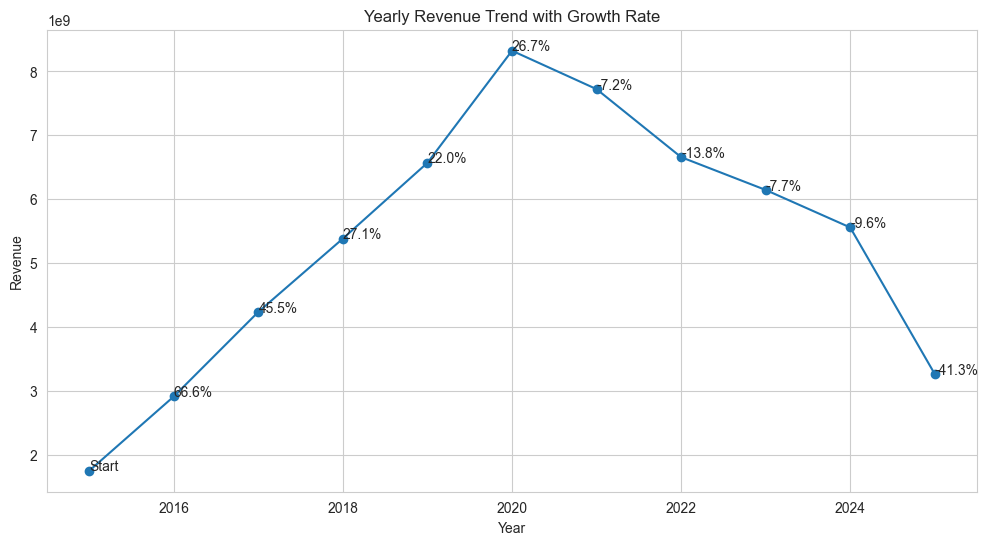

    year  final_amount_inr  growth_pct
0   2015      1.747946e+09         NaN
1   2016      2.911278e+09   66.554191
2   2017      4.235436e+09   45.483746
3   2018      5.382920e+09   27.092460
4   2019      6.569623e+09   22.045731
5   2020      8.323894e+09   26.702761
6   2021      7.722293e+09   -7.227399
7   2022      6.657550e+09  -13.787917
8   2023      6.144042e+09   -7.713169
9   2024      5.556519e+09   -9.562483
10  2025      3.261984e+09  -41.294460
Insight: This chart shows long-term revenue growth and percentage change year over year.


In [ ]:
#1 Revenue trend analysis
yearly_revenue = df.groupby("year", dropna=True)["final_amount_inr"].sum().reset_index()
yearly_revenue["growth_pct"] = yearly_revenue["final_amount_inr"].pct_change() * 100

plt.figure(figsize=(12, 6))
plt.plot(yearly_revenue["year"], yearly_revenue["final_amount_inr"], marker="o")
for i, row in yearly_revenue.iterrows():
    plt.text(row["year"], row["final_amount_inr"], f'{row["growth_pct"]:.1f}%' if pd.notna(row["growth_pct"]) else "Start")
plt.title("Yearly Revenue Trend with Growth Rate")
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

print(yearly_revenue)
print("Insight: This chart shows long-term revenue growth and percentage change year over year.")

In [4]:
category_col = "category_catalog" if "category_catalog" in df.columns else ("category" if "category" in df.columns else None)

if "customer_id" not in df.columns:
    df["customer_id"] = np.nan

if "transaction_id" not in df.columns:
    df["transaction_id"] = np.arange(1, len(df) + 1)

if "product_id" not in df.columns:
    df["product_id"] = np.nan

if "brand" not in df.columns:
    df["brand"] = np.nan

if "payment_method" not in df.columns:
    df["payment_method"] = np.nan

if "customer_city" not in df.columns:
    df["customer_city"] = np.nan

if "customer_state" not in df.columns:
    df["customer_state"] = np.nan

if "is_prime_member" not in df.columns:
    df["is_prime_member"] = np.nan

if "return_status" not in df.columns:
    df["return_status"] = np.nan

print("Category column used:", category_col)

Category column used: category_catalog


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 6)
sns.set_style("whitegrid")

df = pd.read_csv("../data/processed/cleaned_data.csv", low_memory=False)

df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")

if "final_amount_inr" in df.columns:
    df["final_amount_inr"] = pd.to_numeric(df["final_amount_inr"], errors="coerce")

if "original_price_inr" in df.columns:
    df["original_price_inr"] = pd.to_numeric(df["original_price_inr"], errors="coerce")

if "discount_percent" in df.columns:
    df["discount_percent"] = pd.to_numeric(df["discount_percent"], errors="coerce")

if "delivery_days" in df.columns:
    df["delivery_days"] = pd.to_numeric(df["delivery_days"], errors="coerce")

if "customer_rating" in df.columns:
    df["customer_rating"] = pd.to_numeric(df["customer_rating"], errors="coerce")

if "product_rating" in df.columns:
    df["product_rating"] = pd.to_numeric(df["product_rating"], errors="coerce")

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")

print(df.shape)
print(df.columns.tolist())
df.head()

(1127609, 48)
['transaction_id', 'order_date', 'customer_id', 'product_id', 'product_name', 'category', 'subcategory', 'brand', 'original_price_inr', 'discount_percent', 'discounted_price_inr', 'quantity', 'subtotal_inr', 'delivery_charges', 'final_amount_inr', 'customer_city', 'customer_state', 'customer_tier', 'customer_spending_tier', 'customer_age_group', 'payment_method', 'delivery_days', 'delivery_type', 'is_prime_member', 'is_festival_sale', 'festival_name', 'customer_rating', 'return_status', 'order_month', 'order_year', 'order_quarter', 'product_weight_kg', 'is_prime_eligible', 'product_rating', 'source_file', 'product_name_catalog', 'category_catalog', 'subcategory_catalog', 'brand_catalog', 'base_price_2015', 'weight_kg', 'rating', 'is_prime_eligible_catalog', 'launch_year', 'model', 'year', 'month', 'month_name']


,transaction_id,order_date,customer_id,product_id,product_name,category,subcategory,brand,original_price_inr,discount_percent,...,brand_catalog,base_price_2015,weight_kg,rating,is_prime_eligible_catalog,launch_year,model,year,month,month_name
0,TXN_2015_00000001,2015-01-25,CUST_2015_00003884,PROD_000021,Samsung Galaxy S6 16GB Black,electronics,Smartphones,Samsung,123614.29,27.91,...,Samsung,123614.29,0.19,4.7,True,2015,Galaxy S6,2015,1,Jan
1,TXN_2015_00000002,2015-05-01,CUST_2015_00011709,PROD_000055,OnePlus OnePlus 2 16GB White,electronics,Smartphones,OnePlus,54731.86,0.00,...,OnePlus,54731.86,0.20,4.1,True,2015,OnePlus 2,2015,5,May
2,TXN_2015_00000003,2015-01-24,CUST_2015_00004782,PROD_000039,Samsung Galaxy Note 5 64GB Black,electronics,Smartphones,Samsung,97644.25,46.93,...,Samsung,97644.25,0.17,3.3,True,2015,Galaxy Note 5,2015,1,Jan
3,TXN_2015_00000004,2015-01-28,CUST_2015_00008105,PROD_000085,Motorola Moto G (3rd Gen) 16GB Black,electronics,Smartphones,Motorola,21947.26,0.00,...,Motorola,21947.26,0.22,3.5,True,2015,Moto G (3rd Gen),2015,1,Jan
4,TXN_2015_00000005,2015-01-31,CUST_2015_00002955,PROD_000055,OnePlus OnePlus 2 16GB White,electronics,Smartphones,OnePlus,54731.86,0.00,...,OnePlus,54731.86,0.20,4.1,True,2015,OnePlus 2,2015,1,Jan
